# 03 · MLP — V_in=5, V_out=5
### Taller B3-T4 — Redes Neuronales para Forecasting

Notebook individual para **una única combinación** del bucle 4×4. Forma parte de la familia de 16 notebooks `mlp_vin{V}_vout{V}.ipynb` en `03_mlp/`.

Patrón "1 notebook = 1 combo" basado en `BestRunTracker`: el callback persiste automáticamente la mejor ejecución histórica del combo (best.keras + best.json + last.json + history.csv) y reescribe el CSV parcial solo si esta run mejora la `mae_val` previa.

---

**Salidas generadas por este notebook**

| Carpeta | Fichero |
|---|---|
| `08_results/runs/mlp/mlp_vin5_vout5/` | `best.keras`, `best.json`, `last.json`, `history.csv` |
| `08_results/tablas/parciales/` | `mlp_vin5_vout5.csv` (1 fila — solo se sobrescribe si esta run mejora) |
| `08_results/curvas/mlp/` | `mlp_vin5_vout5.png` (curva con baselines superpuestos) |

> ⚠️ Partición cronológica con `random_state=42` (semilla competición) — **no modificar**.
> ⚠️ Para cambiar de combo: duplicar este notebook y modificar **solo** `V_IN, V_OUT` en la celda de constantes.

## 1. Entorno de ejecución

Detección automática Colab / local, montaje de Drive si procede, e inserción de `01_src_compartido` en `sys.path`.

In [1]:
import os, sys

def detect_env():
    try:
        import google.colab
        return 'colab'
    except ImportError:
        return 'local'

ENV = detect_env()

if ENV == 'colab':
    from google.colab import drive
    drive.mount('/content/drive')
    BASE = '/content/drive/MyDrive/Taller4_DL_MIAX'
else:
    BASE = os.path.abspath(os.path.join(os.getcwd(), '..'))

SRC = os.path.join(BASE, '01_src_compartido')
if SRC not in sys.path:
    sys.path.insert(0, SRC)

print(f'> Entorno : {ENV}')
print(f'> BASE    : {BASE}')
print(f'> SRC     : {SRC}')

> Entorno : local
> BASE    : /mnt/c/Users/diego/MIAX/11-nn-forecasting-sp/Taller4_DL_MIAX
> SRC     : /mnt/c/Users/diego/MIAX/11-nn-forecasting-sp/Taller4_DL_MIAX/01_src_compartido


## 2. Importaciones

Librerías estándar, Keras y módulos compartidos. Se inyecta `BASE` en `metrics_utils` para que las funciones de guardado escriban en la ruta correcta.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

from dataset_utils import load_data, create_dataset, get_partitions, TICKERS
import metrics_utils
metrics_utils.BASE_DRIVE = BASE
from metrics_utils import plot_curva, BestRunTracker, resumen_vs_baselines

print(f'> TensorFlow : {tf.__version__}')
print(f'> GPU        : {tf.config.list_physical_devices("GPU")}')

2026-05-10 19:40:46.774390: I tensorflow/core/util/port.cc:110] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-05-10 19:40:46.822590: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-05-10 19:40:47.456203: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


> TensorFlow : 2.13.0
> GPU        : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


2026-05-10 19:40:48.782407: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:981] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-05-10 19:40:48.868519: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:981] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-05-10 19:40:48.868609: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:981] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.


## 3. Configuración de este notebook

**Esta es la única celda específica del combo.** Para crear otro `mlp_vin{V}_vout{V}.ipynb`, duplicar este fichero y cambiar `V_IN`, `V_OUT`.

In [3]:
MODELO   = 'mlp'
V_IN     = 5
V_OUT    = 5
n_assets = len(TICKERS)

# Hiperparámetros de entrenamiento (BestRunTracker los persiste en best.json)
EPOCHS     = 200
BATCH_SIZE = 256
PATIENCE   = 15

print(f'> Combinación: V_in={V_IN}, V_out={V_OUT}')

> Combinación: V_in=5, V_out=5


## 4. Descarga de datos y construcción del dataset

Precios ajustados de los 23 activos vía `yfinance` → log-retornos diarios. Ventanas para esta combinación y partición cronológica (semilla competición = 42).

In [4]:
data, df = load_data()
print(f'> Datos : {data.shape[0]:,} días × {data.shape[1]} activos')
print(f'> Rango : {df.index[0].date()} → {df.index[-1].date()}')

X, Y = create_dataset(data, V_IN, V_OUT)
X_tr, X_val, X_test, Y_tr, Y_val, Y_test = get_partitions(X, Y, val_size=0.2, test_size=0.1)

print(f'> X shape: {X.shape}   Y shape: {Y.shape}')
print(f'> Train: {X_tr.shape[0]:,}  Val: {X_val.shape[0]:,}  Test: {X_test.shape[0]:,}')

> Datos : 16,195 días × 23 activos
> Rango : 1962-01-03 → 2026-05-08
> X shape: (16186, 5, 23)   Y shape: (16186, 23)
> Train: 11,653  Val: 2,914  Test: 1,619


## 5. Definición del modelo MLP

Red densa. La entrada `(V_IN, 23)` se aplana antes de las capas Dense. Loss y métrica: `mae`.

In [5]:
model = keras.Sequential([
    layers.Input(shape=(V_IN, n_assets)),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
layers.Dropout(0.3),
layers.Dense(64, activation='relu'),
layers.Dropout(0.3),
layers.Dense(n_assets),
])
model.compile(optimizer='adam', loss='mae', metrics=['mae'])

model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 flatten (Flatten)           (None, 115)               0         
                                                                 
 dense (Dense)               (None, 128)               14848     
                                                                 
 dropout (Dropout)           (None, 128)               0         
                                                                 
 dense_1 (Dense)             (None, 64)                8256      
                                                                 
 dropout_1 (Dropout)         (None, 64)                0         
                                                                 
 dense_2 (Dense)             (None, 23)                1495      
                                                                 
Total params: 24599 (96.09 KB)
Trainable params: 24599 (

2026-05-10 19:40:53.265497: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:981] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-05-10 19:40:53.265648: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:981] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-05-10 19:40:53.265690: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:981] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-05-10 19:40:53.429021: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:981] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-05-10 19:40:53.429160: I tensorflow/compile

## 6. Entrenamiento

`EarlyStopping` con `restore_best_weights` corta cuando `val_loss` deja de mejorar. `BestRunTracker` (en `callbacks=`) guarda el `best.keras` histórico, escribe `last.json`/`history.csv` siempre y solo sobrescribe el CSV parcial si esta run bate la `mae_val` previa.

In [ ]:
callbacks = [
    EarlyStopping(
        monitor='val_loss', patience=PATIENCE,
        restore_best_weights=True, verbose=1,
    ),
    ReduceLROnPlateau(
        monitor='val_loss', factor=0.4, patience=4,
        min_lr=1e-6, verbose=0,
    ),
    BestRunTracker(
        MODELO, V_IN, V_OUT,
        datasets=(X_tr, Y_tr, X_val, Y_val, X_test, Y_test),
        hparams_extra={'batch_size': BATCH_SIZE, 'patience': PATIENCE, 'epochs_max': EPOCHS},
    ),
]
tracker = callbacks[-1]

history = model.fit(
    X_tr, Y_tr,
    validation_data=(X_val, Y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=callbacks,
    verbose=2,
)

print(f'> Epochs entrenadas : {len(history.history["loss"])}')
print(f'> Best val_loss     : {min(history.history["val_loss"]):.5f}')

## 7. Métricas y persistencia

El tracker ya ha persistido `best.*`, `last.json`, `history.csv` y (si esta run mejora) el CSV parcial. Aquí solo dibujamos la curva con los 3 baselines superpuestos y mostramos la tabla comparativa modelo-vs-baselines.

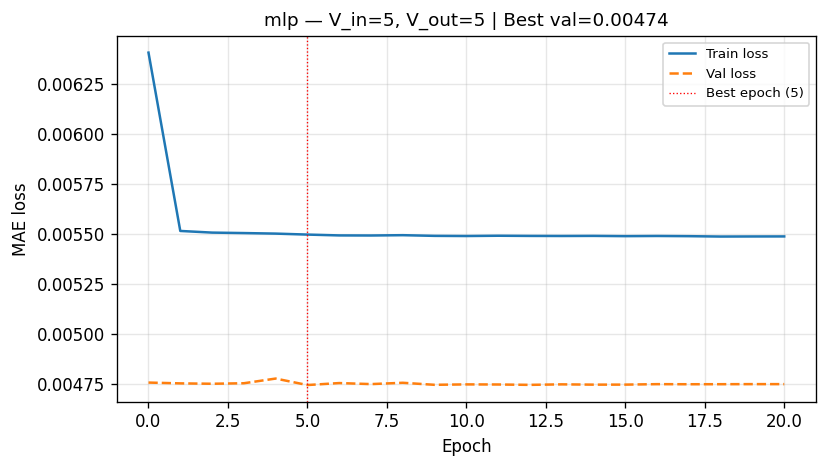


> Comparativa MAE — V_in=5, V_out=5
    baseline   n_params  mae_train  mae_val  mae_test  mejora_test_%
         mlp        NaN    0.00549  0.00474   0.00559            NaN
buy_and_hold    0.00000    0.46390  0.45383   0.49800       98.87728
     trivial    0.00000    0.00783  0.00799   0.00775       27.88430
      lineal 2668.00000    0.00586  0.00599   0.00610        8.38432

> MAE  train=0.00549  val=0.00474  test=0.00559  params=24,599


In [8]:
plot_curva(history, MODELO, V_IN, V_OUT, mostrar_baselines=False, save=True)
plt.show()

resumen_vs_baselines(tracker.maes_last, V_IN, V_OUT, nombre_modelo=MODELO)

maes = tracker.maes_last
print(f'\n> MAE  train={maes["train"]:.5f}  val={maes["val"]:.5f}  test={maes["test"]:.5f}'
      f'  params={model.count_params():,}')